In [1]:
import math
import numpy as np
from scipy.stats import norm
from scipy.special._ufuncs import gammainc
from scipy.optimize import minimize
from scipy.stats import ncx2

In [37]:
######################## direct inversion ######################################
def root_chi2(a, b, u):
    ''' inversion of the non central chi-square distribution '''
    c0 = a
    bnds = [(0., None)]
    res = minimize(equation, c0, args=(a, b, u), bounds=bnds)
    return res.x[0]

def equation(c, a, b, u):
    return 1 - ncx2.cdf(a, b, c) - u  # page 13 step 7 

######################## Absorption probability #################################

def AbsorptionConditionalProb(a, b):
    ''' probability that F_ti+1 is absorbed by the 0 barrier conditional on inital value S0  '''
    cprob = 1. - gammainc(b / 2, a / 2)  # formula (2.10), scipy gammainc is already normalized by gamma(b) 
    return cprob

######################## volatility GBM simulation ##############################

def simulate_Wt(dW, T, N):
    ''' Simulates brownian paths. Vectorization inspired by Scipy cookbook ''' 
    Wt = np.empty((T, N))
    np.cumsum(dW, axis=0, out=Wt)
    return Wt

def simulate_sigma(Wt, sigma0, alpha , t):
    ''' 'Exact' simulation of GBM with mu=0 '''
    return sigma0 * np.exp(alpha * Wt - 0.5 * (alpha ** 2) * t[1:])

######################## integrated variance ####################################
def integrated_variance_small_disturbances(N, rho, alpha, sigmat, dt, dW, U):
    ''' Small disturbance expansion Chen B. & al (2011).'''
    # formula (3.18)
    dW_2, dW_3, dW_4 = np.power(dW, 2), np.power(dW, 3), np.power(dW, 4)
    
    m1 = alpha * dW
    m2 = (1. / 3) * (alpha ** 2) * (2 * dW_2 - dt / 2)
    m3 = (1. / 3) * (alpha ** 3) * (dW_3 - dW * dt) 
    m4 = (1. / 5) * (alpha ** 4) * ((2. / 3) * dW_4 - (3. / 2) * dW_2 * dt + 2 * np.power(dt, 2))
    m = (sigmat ** 2) * dt * (1. + m1 + m2 + m3 + m4)
    
    v = (1. / 3) * (sigmat ** 4) * (alpha ** 2) * np.power(dt, 3)
    # step 3 & 4 of 3.6 discretization scheme
    mu = np.log(m) - (1. / 2) * np.log(1. + v / m ** 2)
    sigma2 = np.log(1. + v / (m ** 2))
    A_t = np.exp(np.sqrt(sigma2) * norm.ppf(U) + mu)
    v_t = (1. - rho ** 2) * A_t
    return v_t


def integrated_variance_trapezoidal(rho, sigma_t, dt):
    sigma2_ti = sigma_t ** 2
    sigma2_ti_1 = shift(sigma_t, -1, fill_value=0.) ** 2
    A_t = ((dt / 2) * (sigma2_ti + sigma2_ti_1))
    v_t = (1. - rho ** 2) * A_t
    return v_t


def shift(arr, num, fill_value=np.nan):
    arr = np.roll(arr, num)
    if num < 0:
        arr[num:] = fill_value
    elif num > 0:
        arr[:num] = fill_value
    return arr


def andersen_QE(ai, b):
    ''' Test for Andersen L. (2008) Quadratic exponential Scheme (Q.E.) '''
    k = 2. - b
    lbda = ai
    s2 = (2 * (k + 2 * lbda))
    m = k + lbda
    psi = s2 / m ** 2 
    return m, psi

def sabrMC(F0=0.04, sigma0=0.07, alpha=0.5, beta=0.25, rho=0.4, psi_threshold=2., n_years=1.0, T=252, N=1000, trapezoidal_integrated_variance=False):
# def sabrMC(F0=0.04, sigma0=0.07, alpha=0.001, beta=0.999, rho=0, psi_threshold=2., n_years=1.0, T=252, N=1000, trapezoidal_integrated_variance=False):
    """Simulates a SABR process with absoption at 0 with the given parameters.
       The Sigma, Alpha, Beta, Rho (SABR) model originates from Hagan S. et al. (2002).
       The simulation algorithm is taken from Chen B., Osterlee C. W. and van der Weide H. (2011)

       Parameters
       ----------
       F0: Underlying (most often a forward rate) initial value
       
       sigma0: Initial stochastic volatility

       alpha: Vol-vol parameter of SABR
             
       beta: Beta parameter of SABR
       
       rho: Stochastic process correlation 
       
       psi_threshold: Refers to the threshold of applicability of Andersen L. (2008)
           Quadratic Exponential (QE) algorithm.
       
       n_years: Number of year fraction for the simulation
    
       T: Number of steps
       
       N: Number of simulated paths
       
       trapezoidal_integrated_variance: use trapezoidal integrated variance instead of small disturbances

       Returns
       -------
       Ft: type numpy.ndarray, shape (T+1, N)
           An array with each path stored in a column.

       Reference
       ---------
       * "Managing Smile Risk",
       Patrick S. Hagan, Deep Kumar, Andrew S. Lesniewski,and Diana E. Woodward (2002)
       * "Efficient simulation of the heston stochastic volatility model"
       Andersen L. Journal of Computational Finance 11:3 (2008) 1–22.
       * "Simulation of the CEV process and the local martingale property."
       A. E. Lindsay, D. R. Brecher (2010)
       * "Efficient unbiased simulation scheme for the SABR stochastic volatility model"
       Bin Chen, Cornelis W. Oosterl, Hans van der Weide (2011)
    """
    
    tis = np.linspace(1E-10, n_years, T + 1)  # grid - vector of time steps - starts at 1e-10 to avoid unpleasantness
    t = np.expand_dims(tis, axis=-1)  # for numpy broadcasting 
    dt = 1. / (T)
    
    
    # Distributions samples
    dW2 = np.random.normal(0.0, math.sqrt(dt), (T, N))
    U1 = np.random.uniform(size=(T, N))
    U = np.random.uniform(size=(T, N))
    Z = np.random.normal(0.0, 1., (T, N))
    W2t = simulate_Wt(dW2, T, N)
    
    # vol process
    sigma_t = simulate_sigma(W2t, sigma0, alpha, t)
    
    # integrated variance- values are integrals between ti-1 and ti 
    # not integrals over the whole interval [0,ti] distribution is approx. log normal
    if trapezoidal_integrated_variance:
        v_t = integrated_variance_trapezoidal(rho, sigma_t, dt)
    else:
        v_t = integrated_variance_small_disturbances(N, rho, alpha, sigma_t, dt, dW2, U1)
        
    b = 2. - ((1. - 2. * beta - (1. - beta) * (rho ** 2)) / ((1. - beta) * (1. - rho ** 2)))

    # initialize underlying values
    Ft = np.zeros((T-1, N))
    Ft = np.insert(Ft, 0, F0 * np.ones(N), axis=0)
    
    
   
    for n in range(0, N):
        for ti in range(1, T):
            
            if Ft[ti - 1, n] == 0.:
                Ft[ti, n] = 0.
                continue
            a = (1. / v_t[ti - 1, n]) * (((Ft[ti - 1, n] ** (1. - beta)) / (1. - beta) + (rho / alpha) * (sigma_t[ti, n] - sigma_t[ti - 1, n])) ** 2)
            # absorption probabilities Formula 2.10
            pr_zero = AbsorptionConditionalProb(a, b)
            if pr_zero > U[ti - 1, n]:
                Ft[ti, n] = 0.
                continue
            
            m, psi = andersen_QE(a, b)

            if m >= 0 and psi <= psi_threshold:
                # Formula 3.9: simulation for high values
                e2 = (2. / psi) - 1. + math.sqrt(2. / psi) * math.sqrt((2. / psi) - 1.)
                d = m / (1. + e2)
                Ft[ti, n] = np.power(((1. - beta) ** 2) * v_t[ti - 1, n] * d * ((math.sqrt(e2) + Z[ti - 1, n]) ** 2), 1. / (2.* (1. - beta))) 
                
            elif psi > psi_threshold or (m < 0 and psi <= psi_threshold):
                # direct inversion for small values
                c_star = root_chi2(a, b, U[ti - 1, n])
                Ft[ti, n] = np.power(c_star * ((1. - beta) ** 2) * v_t[ti - 1, n], 1. / (2. - 2. * beta))

            # print Ft[ti, n]
        
    return Ft

In [38]:
l = sabrMC()

In [39]:
F0 = 0.04
K = 0.03
T = 1.0
sigma = 0.07
r = 0.02

In [40]:
# Payoff at maturity
payoffs = np.maximum(l[-1, :] - K, 0)

# Discounted expected payoff
option_price = np.exp(-r * T) * np.mean(payoffs)
print(option_price)

0.01658215624598786


In [25]:
from scipy.stats import norm
import numpy as np

def black_scholes_call(F0, K, T, sigma, r=0.0):
    d1 = (np.log(F0 / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return np.exp(-r * T) * (F0 * norm.cdf(d1) - K * norm.cdf(d2))

bs_price = black_scholes_call(F0, K, T, sigma, r)
print("Black-Scholes call price:", bs_price)

Black-Scholes call price: 0.009801997111207543


In [48]:
strikes = np.linspace(0.03, 0.05, 200)  # 20 strikes around F0

In [54]:
l = sabrMC(F0=0.04, sigma0=0.07, alpha=0.001, beta=0.999, rho=0.0, psi_threshold=2., n_years=1.0, T=252, N=10000, trapezoidal_integrated_variance=False)

In [55]:
sabr_prices = []

for K in strikes:
    payoffs = np.maximum(l[-1, :] - K, 0)  # European call
    price = np.exp(-r*T) * np.mean(payoffs)
    sabr_prices.append(price)

In [56]:
from scipy.stats import norm
from scipy.optimize import brentq

def bs_call_price(F0, K, T, sigma, r=0.0):
    d1 = (np.log(F0/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return np.exp(-r*T) * (F0*norm.cdf(d1) - K*norm.cdf(d2))

def implied_vol(price, F0, K, T, r=0.0):
    # solve for sigma that gives BS price = price
    def f(sigma):
        return bs_call_price(F0, K, T, sigma, r) - price
    return brentq(f, 1e-6, 3.0)  # root finding

In [57]:
implied_vols = [implied_vol(p, F0, K, T, r) for p, K in zip(sabr_prices, strikes)]

ValueError: f(a) and f(b) must have different signs

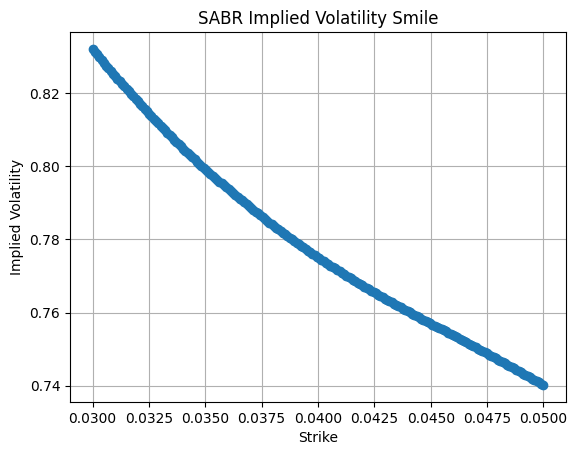

In [52]:
import matplotlib.pyplot as plt

plt.plot(strikes, implied_vols, marker='o')
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("SABR Implied Volatility Smile")
plt.grid(True)
plt.show()